# 13 · GSE232381 · bulk_RNA_seq · WGCNA soft threshold (exploratory)

Reads `expression.rds`. Writes `data/run_artifacts/GSE232381/wgcna_input.rds`.

**This analysis is exploratory.** The WGCNA FAQ: "We do not recommend attempting WGCNA on a data set
consisting of fewer than 15 samples", and ideally at least 20. This study has 16.

**Samples:** all 16. **Genes:** all genes kept in notebook 12. **Network:** signed.
**Rule for β:** the lowest power with scale-free R² ≥ 0.80; if none, the FAQ fallback for a signed
network with fewer than 20 samples is 18.

In [1]:
if (!requireNamespace("WGCNA", quietly = TRUE)) install.packages("WGCNA", repos = "https://cloud.r-project.org")
suppressMessages(library(WGCNA))
source("../src/paths.R")
x <- readRDS(art("GSE232381", "expression.rds"))
datExpr <- t(x$E)
dim(datExpr)

[1]    16 16605

**Check.** `goodSamplesGenes` removes genes with zero variance or too many missing values.

In [2]:
gsg <- goodSamplesGenes(datExpr, verbose = 0)
c(genes_flagged = sum(!gsg$goodGenes), samples_flagged = sum(!gsg$goodSamples))
datExpr <- datExpr[gsg$goodSamples, gsg$goodGenes]
dim(datExpr)

genes_flagged samples_flagged 
              0               0

[1]    16 16605

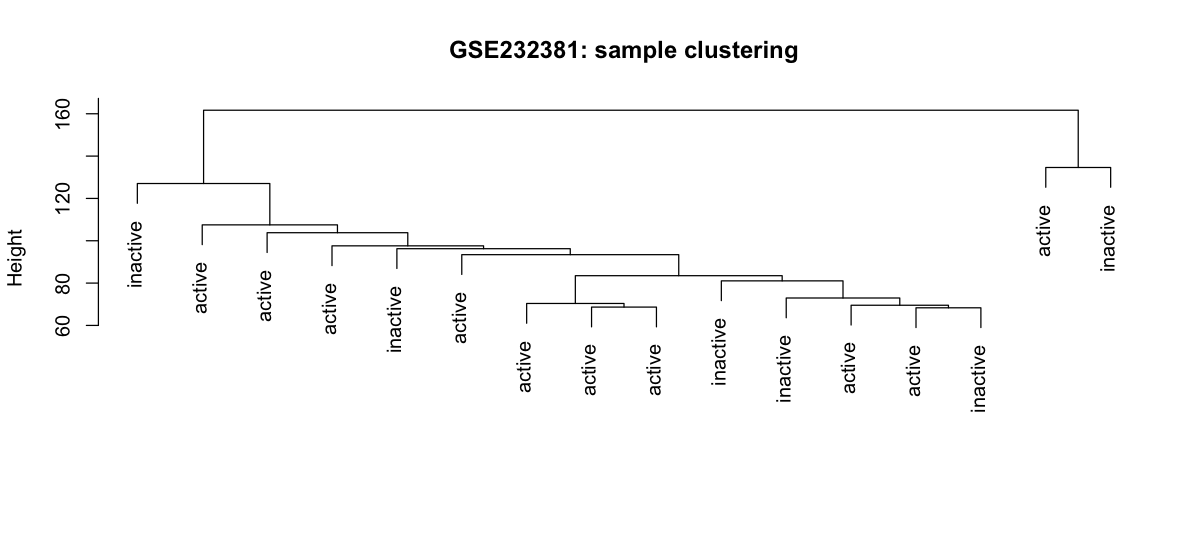

In [3]:
options(repr.plot.width = 10, repr.plot.height = 4.5)
plot(hclust(dist(datExpr), method = "average"), labels = ifelse(x$meta[rownames(datExpr), "ln_active"] == 1, "active", "inactive"),
     main = "GSE232381: sample clustering", xlab = "", sub = "")

In [4]:
powers <- c(1:10, seq(12, 30, 2))
invisible(capture.output(sft <- pickSoftThreshold(datExpr, powerVector = powers, networkType = "signed", verbose = 0)))
fit <- data.frame(power = sft$fitIndices$Power,
                  scale_free_R2 = round(-sign(sft$fitIndices$slope) * sft$fitIndices$SFT.R.sq, 3),
                  mean_connectivity = round(sft$fitIndices$mean.k., 1))
fit
reached <- fit$power[fit$scale_free_R2 >= 0.80]
POWER <- if (length(reached)) min(reached) else 18
c(power = POWER, rule = if (length(reached)) "lowest power with R2 >= 0.80" else "FAQ fallback, signed, < 20 samples")

Warning message:
“executing %dopar% sequentially: no parallel backend registered”


power,scale_free_R2,mean_connectivity
<dbl>,<dbl>,<dbl>
1,-0.054,8346.7
2,-0.133,4898.3
3,0.010,3176.6
4,0.077,2206.8
5,0.189,1611.8
6,0.368,1222.7
7,0.547,955.4
8,0.670,764.4
9,0.759,623.7


power                           rule 
                          "10" "lowest power with R2 >= 0.80"

In [5]:
saveRDS(list(datExpr = datExpr, power = POWER, fit = fit), art("GSE232381", "wgcna_input.rds"))

**Result.** 16 samples × 16,605 genes. β = 10, the lowest power with R² ≥ 0.80 (R² = 0.81).